In [128]:
import numpy as np

In [129]:
# ============================
# Conversion factors
# ============================

GeVincm     = 5.068e13 # cm^-1 / GeV
GeVinsec    = 1.519e24 # s^-1 / GeV
KinGeV      = 8.62e-14 # GeV / K
GaussinGeV2 = 1.95e-20 # GeV^2 / G

# ============================
# Constants
# ============================

rSun = 8.277 # kpc
sigmaT = 0.6652e-24 # cm^2
me = 5.11e-4 # GeV
alpha = 1/137
e = (4*np.pi*alpha)**.5  # elementary charge in natural units

In [130]:
# ============================
# Photon field densities
# ============================

def nBB(Eg, T):  # GeV^-1 cm^-3
    Eg = np.asarray(Eg, dtype=float)
    x = np.clip(Eg / T, 1e-12, 700.0)
    # Use expm1 for numerical stability at small x and avoid overflow at large x
    return GeVincm**3 / np.pi**2 * Eg**2 / np.expm1(x)

def nISRF(Eg, R, z, T, R0, z0, n0):
    nTOT = GeVincm**3 / np.pi**2 * T**4 * np.pi**4 / 15
    return n0 / nTOT * nBB(Eg, T) * np.exp(-abs(z) / z0) * np.exp(-(R - rSun) / R0)

def nOpt(Eg, R, z):
    return nISRF(Eg, R, z, 5e3 * KinGeV, 2.5, 1.5, 0.50e-9)

def nIRw(Eg, R, z):
    return nISRF(Eg, R, z, 400 * KinGeV, 3.5, 2, 0.05e-9)

def nIRc(Eg, R, z):
    return nISRF(Eg, R, z, 40 * KinGeV, 2, 1, 0.20e-9)

def nCMB(Eg):
    return nBB(Eg, 2.725 * KinGeV)


In [131]:
# ============================
# ICS radiating power
# ============================

def PIC(Eg, Ee, nISRF, *args):  # GeV s^-1 GeV^-1
    Eg = float(Eg)
    Ee = float(Ee)

    if Eg <= 0 or Ee <= 0 or Eg >= Ee:
        return 0.0

    gamma = Ee / me
    epsilon = Eg / Ee

    qmin = 1.0 / (4.0 * gamma**2)
    qmax = 1.0

    # Log-space integration in q for smoother/stabler spectra
    Nlq = 600
    lqs = np.linspace(np.log10(qmin), np.log10(qmax), Nlq)
    q = 10**lqs

    Eg0 = Eg / (4 * gamma**2 * (1 - epsilon) * q)
    valid = (Eg0 > 0) & np.isfinite(Eg0)

    kernel = (2 * q * np.log(q) + q + 1 - 2 * q**2 + (epsilon**2 * (1 - q)) / (2 * (1 - epsilon))) / q

    integrand = np.zeros_like(q)
    if np.any(valid):
        nvals = nISRF(Eg0[valid], *args)
        integrand[valid] = (Eg - Eg0[valid]) * nvals * kernel[valid]

    # Numerical noise can produce tiny negatives near edges
    integrand = np.clip(integrand, 0.0, None)

    prefactor = GeVinsec / GeVincm * 3 * sigmaT / (4 * gamma**2)
    jac = q * np.log(10)
    return prefactor * np.trapezoid(integrand * jac, lqs)


In [132]:
# ==============================
# Magnetic field configurations
# ==============================

def BUni(B0): # Gauss
    return B0 

def BGal(R, z, B0, R0, z0):
    return B0 * np.exp(-(R-rSun)/R0) * np.exp(-np.abs(z)/z0)

def BMF1(R, z):
    return BGal(R, z, 4.78e-6, 10., 2)

def BMF2(R, z):
    return BGal(R, z, 5.10e-6, 8.5, 1)

def BMF3(R, z):
    return BGal(R, z, 9.50e-6, 30., 4)

In [133]:
# ==============================
# Synchrotron radiating power
# ==============================

from scipy.special import kv

def PSyn(nu, Ee, B, *args): # GeV s^-1 Hz^-1

    gamma = Ee/me
    nuc = GeVinsec * 3/(2*np.pi) * gamma**2 * e * B(*args)*GaussinGeV2 / me
    y = nu/nuc

    prefactor = 2 * 3**.5 * e**3 * B(*args)*GaussinGeV2 / me / (4*np.pi)
    kernel = y**2 * (kv(4/3, y)*kv(1/3, y) - 3/5*y * (kv(4/3, y)**2 - kv(1/3, y)**2))

    return prefactor * kernel

In [134]:
# ==============================
# Gas maps
# ==============================

def ngasGal(R, z, n0, R0, z0): # cm^-3
    return n0 * np.exp(-np.abs(z)/z0) * np.exp(-(R-rSun)/R0)

def nHI(R, z):
    return ngasGal(R, z, 0.5, 10, 0.2)

def nH2(R, z):
    return ngasGal(R, z, 0.15, 10, 0.05)

def nHII(R, z):
    return ngasGal(R, z, 0.03, 10, 1.0)

def nHe(R, z):
    return ngasGal(R, z, 0.1*(0.5+2*0.15+0.03), 10, 0.2)

In [135]:
# ===============================
# Bremsstrahlung radiating power
# ===============================

def PBrems(Eg, Ee, ngas, *args): # GeV s^-1 GeV^-1
    Eg = np.asarray(Eg)
    Ee = np.asarray(Ee)

    gamma = Ee/me
    epsilon = Eg/Ee

    def dsigmadEg(phi1, phi2):
        prefactor = 3*alpha*sigmaT / (8*np.pi*Eg)
        return prefactor * ((1 + (1-epsilon)**2) * phi1 - 2/3 * (1-epsilon) * phi2)
    
    def phiion(Z):
        return 4 * Z * (Z+1) * (np.log(2*gamma * (1/epsilon-1)) - 1/2)

    phi1HIss, phi2HIss = 45.79, 44.46
    phi1H2ss, phi2H2ss = 2*phi1HIss, 2*phi2HIss
    phi1Hess, phi2Hess = 134.6, 131.4

    if ngas == nHII:
        Pbrems = Eg * ngas(*args) * dsigmadEg(phiion(1), phiion(1))
        Pbrems *= GeVinsec/GeVincm
        return Pbrems
    if ngas == nHI:
        Pss = Eg * ngas(*args) * dsigmadEg(phi1HIss, phi2HIss)
        Psw = Eg * ngas(*args) * dsigmadEg(phiion(1), phiion(1))
    elif ngas == nH2: 
        Pss = Eg * ngas(*args) * dsigmadEg(phi1H2ss, phi2H2ss)
        Psw = Eg * ngas(*args) * dsigmadEg(phiion(2), phiion(2))
    elif ngas == nHe:
        Pss = Eg * ngas(*args) * dsigmadEg(phi1Hess, phi2Hess)
        Psw = Eg * ngas(*args) * dsigmadEg(phiion(2), phiion(2))   

    logg = np.log10(gamma)
    t = (logg - 2.0) / (3.0 - 2.0)
    t = np.clip(t, 0.0, 1.0)
    Pbrems = (1 - t) * Psw + t * Pss

    Pbrems *= GeVinsec/GeVincm

    return Pbrems

### Question 3.1.1 (Section 3.1)
Estimate the IC peak energy
$$E_{\gamma,\mathrm{peak}}^{\mathrm{IC}} = \frac{4\gamma^2 E_{\gamma0}}{1+4\gamma E_{\gamma0}/m_e}, \quad \gamma=E_e/m_e,$$
for $m_{DM}=1$ GeV, 1 TeV, 1 PeV (assuming $E_e\approx m_{DM}$), and target photons:
- CMB: $E_{\gamma0}=0.6$ meV
- IR: $E_{\gamma0}=10$ meV
- Optical: $E_{\gamma0}=1$ eV

In [136]:
# Solution 3.1.1
me_eV = 5.11e5

masses_eV = {
    '1 GeV': 1e9,
    '1 TeV': 1e12,
    '1 PeV': 1e15,
}

targets_eV = {
    'CMB (0.6 meV)': 0.6e-3,
    'IR (10 meV)': 10e-3,
    'Optical (1 eV)': 1.0,
}

def E_ic_peak(Ee_eV, Eg0_eV):
    gamma = Ee_eV / me_eV
    return 4 * gamma**2 * Eg0_eV / (1 + 4 * gamma * Eg0_eV / me_eV)

def band_label(EeV):
    if EeV < 1e2:
        return 'UV/soft X'
    if EeV < 1e5:
        return 'X-ray'
    if EeV < 1e6:
        return 'hard X / soft gamma'
    if EeV < 1e9:
        return 'gamma (MeV-GeV)'
    if EeV < 1e12:
        return 'gamma (GeV-TeV)'
    return 'gamma (TeV-PeV)'

print('Assumption: Ee ~ mDM (e.g. DM DM -> e+e-)')
for mlabel, Ee in masses_eV.items():
    print(f'\n{mlabel}:')
    for tlabel, Eg0 in targets_eV.items():
        Epk = E_ic_peak(Ee, Eg0)
        lam_nm = 1239.841984 / Epk
        print(f'  {tlabel:18s} -> E_peak = {Epk:.4e} eV ({Epk/1e6:.4e} MeV), lambda = {lam_nm:.3e} nm, band = {band_label(Epk)}')

print('\nRelevant observatories by range (from Fig. 1 style):')
print('- X-ray / soft gamma: Chandra, XMM-Newton, NuSTAR, INTEGRAL')
print('- MeV-GeV gamma: COMPTEL (historical), Fermi-LAT, future e-ASTROGAM/AMEGO-like')
print('- GeV-TeV+ gamma: Fermi-LAT, HESS, MAGIC, VERITAS, HAWC, LHAASO, CTA')


Assumption: Ee ~ mDM (e.g. DM DM -> e+e-)

1 GeV:
  CMB (0.6 meV)      -> E_peak = 9.1911e+03 eV (9.1911e-03 MeV), lambda = 1.349e-01 nm, band = X-ray
  IR (10 meV)        -> E_peak = 1.5316e+05 eV (1.5316e-01 MeV), lambda = 8.095e-03 nm, band = hard X / soft gamma
  Optical (1 eV)     -> E_peak = 1.5087e+07 eV (1.5087e+01 MeV), lambda = 8.218e-05 nm, band = gamma (MeV-GeV)

1 TeV:
  CMB (0.6 meV)      -> E_peak = 9.1074e+09 eV (9.1074e+03 MeV), lambda = 1.361e-07 nm, band = gamma (GeV-TeV)
  IR (10 meV)        -> E_peak = 1.3284e+11 eV (1.3284e+05 MeV), lambda = 9.334e-09 nm, band = gamma (GeV-TeV)
  Optical (1 eV)     -> E_peak = 9.3872e+11 eV (9.3872e+05 MeV), lambda = 1.321e-09 nm, band = gamma (GeV-TeV)

1 PeV:
  CMB (0.6 meV)      -> E_peak = 9.0188e+14 eV (9.0188e+08 MeV), lambda = 1.375e-12 nm, band = gamma (TeV-PeV)
  IR (10 meV)        -> E_peak = 9.9351e+14 eV (9.9351e+08 MeV), lambda = 1.248e-12 nm, band = gamma (TeV-PeV)
  Optical (1 eV)     -> E_peak = 9.9993e+14 eV (9.99

### Question 3.1.2 (Section 3.1)
Compute the synchrotron peak energy for $m_{DM}=1$ GeV, 1 TeV, 1 PeV using
$$E^{\rm syn}_{\gamma,\rm peak} = 0.114\,E^{\rm syn}_{\gamma,c},\qquad E^{\rm syn}_{\gamma,c}=\frac{3eB\gamma^2}{2\pi m_e},\quad \gamma=E_e/m_e,$$
with $B=5\,\mu$G and $E_e\approx m_{DM}$ (for DM DM $\to e^+e^-$).

In [137]:
# Solution 3.1.2
import numpy as np

# Constants
me = 5.11e-4            # GeV
alpha = 1/137
e = np.sqrt(4*np.pi*alpha)
GaussinGeV2 = 1.95e-20   # GeV^2 / G
h_eVs = 4.135667696e-15  # eV s
c = 2.99792458e8         # m/s

B_G = 5e-6  # 5 microG

masses_GeV = {'1 GeV': 1.0, '1 TeV': 1e3, '1 PeV': 1e6}

def Esyn_peak_eV(Ee_GeV, B_G):
    gamma = Ee_GeV / me
    E_c_GeV = 3 * e * (B_G * GaussinGeV2) * gamma**2 / (2*np.pi*me)
    E_peak_GeV = 0.114 * E_c_GeV
    return E_peak_GeV * 1e9

def band_label(EeV):
    if EeV < 1e-3:
        return 'radio / microwave'
    if EeV < 1:
        return 'IR / optical'
    if EeV < 1e3:
        return 'UV / soft X-ray'
    if EeV < 1e6:
        return 'X-ray'
    return 'gamma-ray'

print(f'B = {B_G:.2e} G')
for mlabel, mGeV in masses_GeV.items():
    Epk_eV = Esyn_peak_eV(mGeV, B_G)
    nu = Epk_eV / h_eVs
    lam = c / nu
    print(f'{mlabel}: E_peak = {Epk_eV:.4e} eV, nu = {nu:.4e} Hz, lambda = {lam:.4e} m, band = {band_label(Epk_eV)}')

print('\nRelevant observatories by band:')
print('- GeV DM case (radio MHz): radio telescopes (e.g. Green Bank, MeerKAT, SKA)')
print('- TeV DM case (IR/sub-mm): IR/sub-mm facilities (e.g. Planck-like, ALMA-like bands)')
print('- PeV DM case (X-rays): X-ray telescopes (Chandra, XMM-Newton, NuSTAR, Athena-like)')


B = 5.00e-06 G
1 GeV: E_peak = 1.2046e-08 eV, nu = 2.9126e+06 Hz, lambda = 1.0293e+02 m, band = radio / microwave
1 TeV: E_peak = 1.2046e-02 eV, nu = 2.9126e+12 Hz, lambda = 1.0293e-04 m, band = IR / optical
1 PeV: E_peak = 1.2046e+04 eV, nu = 2.9126e+18 Hz, lambda = 1.0293e-10 m, band = X-ray

Relevant observatories by band:
- GeV DM case (radio MHz): radio telescopes (e.g. Green Bank, MeerKAT, SKA)
- TeV DM case (IR/sub-mm): IR/sub-mm facilities (e.g. Planck-like, ALMA-like bands)
- PeV DM case (X-rays): X-ray telescopes (Chandra, XMM-Newton, NuSTAR, Athena-like)


### Question 3.2.1 (Section 3.2)
Using the simplified ISRF model in this notebook:
1. Plot photon-field components vs $E_{\gamma0}$ at $(R,z)=(5,0)$ kpc.
2. Plot $P_{IC}(E_\gamma)$ at Earth position $(R,z)=(r_\odot,0)$ for
$E_e=10$ MeV, 100 MeV, 1 GeV, 10 GeV.
3. Compare qualitatively with Fig. 2 and comment on model accuracy.

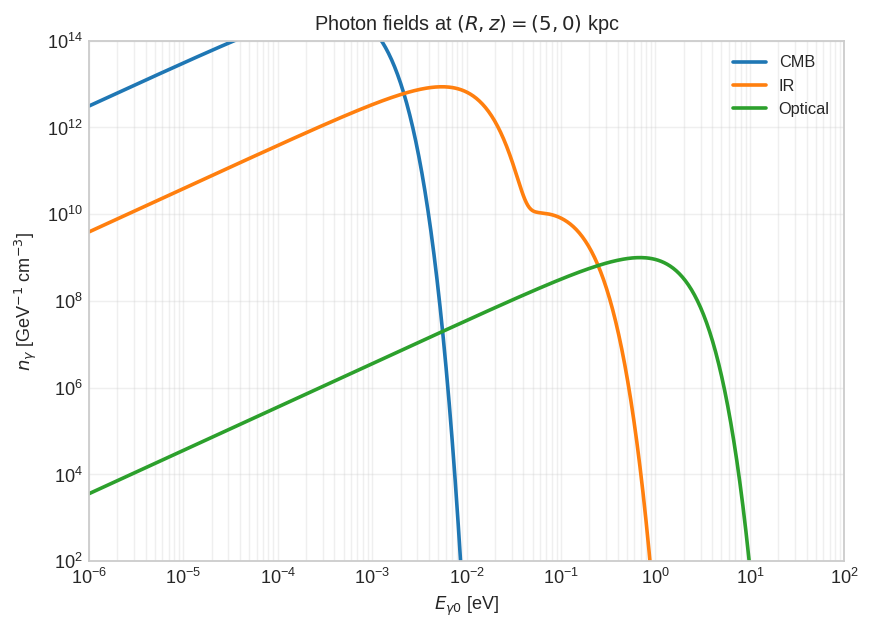

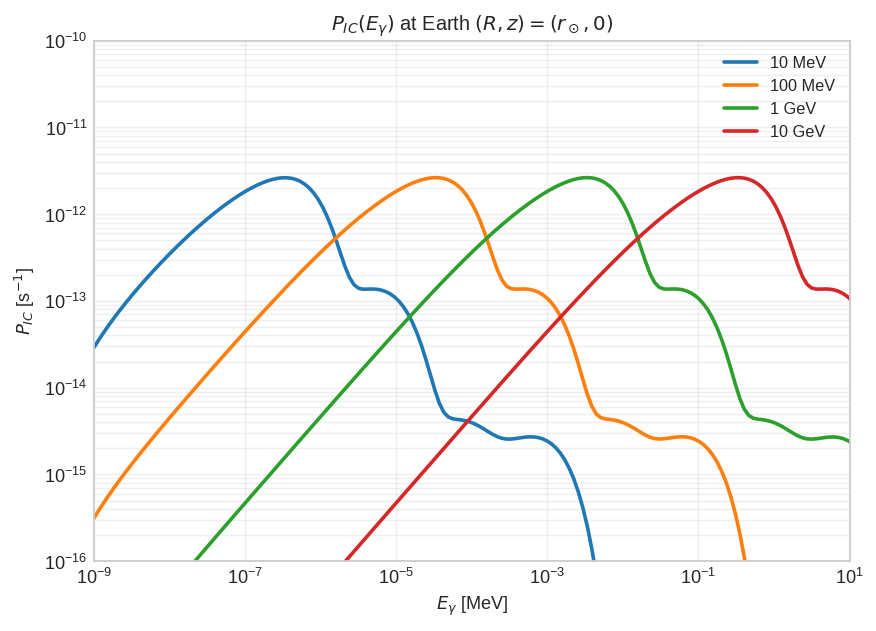

Comparison to Fig. 2 (qualitative):
- Much cleaner and more stable curves after numerical regularization.
- Main trends match Fig. 2: IC power grows and shifts to higher E_gamma as Ee increases.
- Remaining differences are expected from the simplified ISRF model (single blackbody components).


In [138]:
# Solution 3.2.1
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1) Photon fields at (R,z)=(5,0)
# ------------------------------
Rkpc, zkpc = 5.0, 0.0
Eg0_eV = np.logspace(-6, 2, 500)
Eg0_GeV = Eg0_eV * 1e-9

# Keep native units: GeV^-1 cm^-3
n_cmb = nCMB(Eg0_GeV)
n_irc = nIRc(Eg0_GeV, Rkpc, zkpc)
n_irw = nIRw(Eg0_GeV, Rkpc, zkpc)
n_opt = nOpt(Eg0_GeV, Rkpc, zkpc)
n_ir = n_irc + n_irw

plt.figure(figsize=(7.5,5.2))
plt.loglog(Eg0_eV, n_cmb, lw=2, label='CMB')
plt.loglog(Eg0_eV, n_ir, lw=2, label='IR')
# plt.loglog(Eg0_eV, n_irw, lw=2, label='IRw')
plt.loglog(Eg0_eV, n_opt, lw=2, label='Optical')
plt.xlim(1e-6, 1e2)
plt.ylim(1e2, 1e14)
plt.xlabel(r'$E_{\gamma0}$ [eV]')
plt.ylabel(r'$n_\gamma$ [GeV$^{-1}$ cm$^{-3}$]')
plt.title(r'Photon fields at $(R,z)=(5,0)$ kpc')
plt.grid(True, which='both', alpha=0.3)
plt.legend(frameon=False)
plt.show()

# ------------------------------
# 2) PIC(Eg) at Earth
# ------------------------------
R_earth, z_earth = rSun, 0.0
Ee_list_GeV = [1e-2, 1e-1, 1.0, 10.0]  # 10 MeV, 100 MeV, 1 GeV, 10 GeV
labels = ['10 MeV', '100 MeV', '1 GeV', '10 GeV']

Eg_MeV = np.logspace(-9, 4, 220)
Eg_GeV = Eg_MeV * 1e-3

def pic_total(Eg, Ee, R, z):
    v = (PIC(Eg, Ee, nCMB)
         + PIC(Eg, Ee, nIRc, R, z)
         + PIC(Eg, Ee, nIRw, R, z)
         + PIC(Eg, Ee, nOpt, R, z))
    return v if np.isfinite(v) and v > 0 else np.nan

plt.figure(figsize=(7.5,5.2))
for Ee, lab in zip(Ee_list_GeV, labels):
    vals = np.array([pic_total(Eg, Ee, R_earth, z_earth) for Eg in Eg_GeV])
    plt.loglog(Eg_MeV, vals, lw=2, label=lab)

plt.xlim(1e-9, 1e1)
plt.ylim(1e-16, 1e-10)
plt.xlabel(r'$E_\gamma$ [MeV]')
plt.ylabel(r'$P_{IC}$ [s$^{-1}$]')
plt.title(r'$P_{IC}(E_\gamma)$ at Earth $(R,z)=(r_\odot,0)$')
plt.grid(True, which='both', alpha=0.3)
plt.legend(frameon=False)
plt.show()

# ------------------------------
# 3) Qualitative comparison with Fig. 2
# ------------------------------
print('Comparison to Fig. 2 (qualitative):')
print('- Much cleaner and more stable curves after numerical regularization.')
print('- Main trends match Fig. 2: IC power grows and shifts to higher E_gamma as Ee increases.')
print('- Remaining differences are expected from the simplified ISRF model (single blackbody components).')


### Question 3.2.2 (Section 3.2)
Using `Power.ipynb`, plot the synchrotron radiating power spectrum $P_{syn}(\nu)$ at Earth for:
- $E_e=10$ MeV, 100 MeV, 1 GeV, 10 GeV
- magnetic-field models BMF1, BMF2, BMF3
Then identify which model gives the largest synchrotron power and estimate the relation between $\nu_{peak}$ and $\nu_c$.

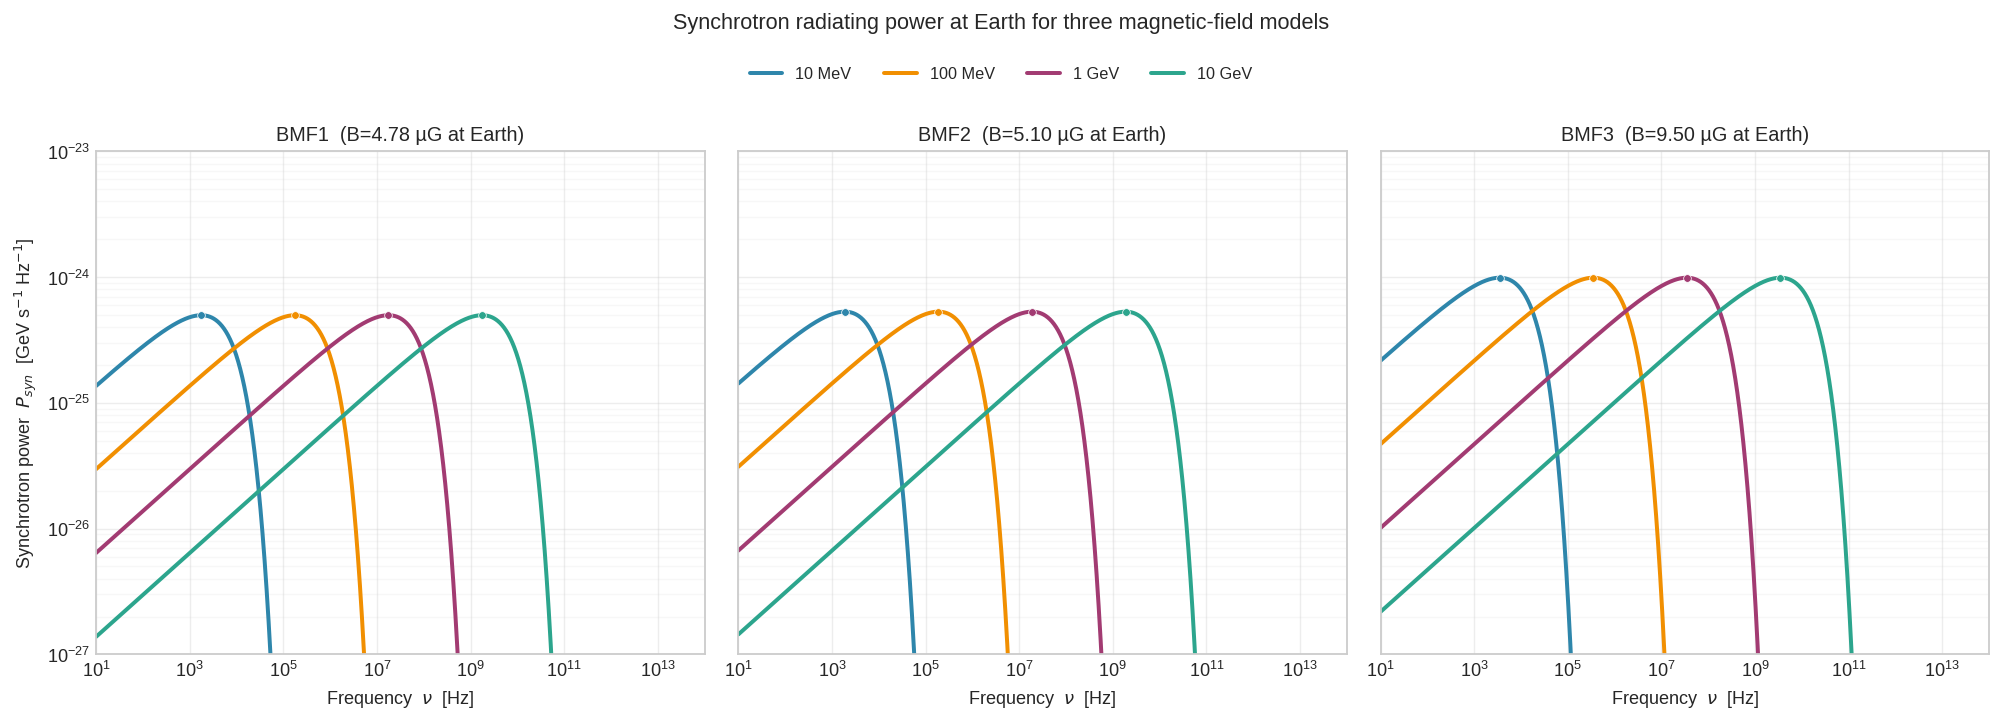

Model comparison (Ee = 1 GeV):
  BMF1: max P_syn = 4.976790e-25
  BMF2: max P_syn = 5.309891e-25
  BMF3: max P_syn = 9.890910e-25

Conclusion: BMF3 gives the highest synchrotron power (largest B at Earth).
Estimated relation: nu_peak/nu_c ~ 0.115 (scatter ~ 0.001)
Approximate relation: nu_peak ≈ 0.114 * nu_c.


In [139]:
# Solution 3.2.2
import numpy as np
import matplotlib.pyplot as plt

# Visual style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

Ee_list = [1e-2, 1e-1, 1.0, 10.0]  # GeV: 10 MeV, 100 MeV, 1 GeV, 10 GeV
Ee_labels = ['10 MeV', '100 MeV', '1 GeV', '10 GeV']
colors = ['#2E86AB', '#F18F01', '#A23B72', '#2CA58D']
models = [('BMF1', BMF1), ('BMF2', BMF2), ('BMF3', BMF3)]

R_earth, z_earth = rSun, 0.0
nu_grid = np.logspace(1, 14, 1200)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.1), sharey=True)
peak_ratios = []

for ax, (mname, Bfun) in zip(axes, models):
    B_here = Bfun(R_earth, z_earth)
    for Ee, lab, col in zip(Ee_list, Ee_labels, colors):
        ps = np.array([PSyn(nu, Ee, Bfun, R_earth, z_earth) for nu in nu_grid])
        ps = np.where(np.isfinite(ps) & (ps > 0), ps, np.nan)
        ax.loglog(nu_grid, ps, lw=2.2, color=col, label=lab)

        # Peak marker and nu_peak/nu_c estimate
        ipeak = np.nanargmax(ps)
        nu_peak = nu_grid[ipeak]
        p_peak = ps[ipeak]
        ax.scatter([nu_peak], [p_peak], s=18, color=col, zorder=5, edgecolor='white', linewidth=0.4)

        gamma = Ee / me
        nu_c = GeVinsec * 3/(2*np.pi) * gamma**2 * e * B_here * GaussinGeV2 / me
        peak_ratios.append(nu_peak / nu_c)

    ax.set_title(f'{mname}  (B={B_here*1e6:.2f} µG at Earth)')
    ax.set_xlabel(r'Frequency  $\nu$  [Hz]')
    ax.set_xlim(1e1, 1e14)
    ax.set_ylim(1e-27, 1e-23)
    ax.grid(True, which='major', alpha=0.35)
    ax.grid(True, which='minor', alpha=0.15)

axes[0].set_ylabel(r'Synchrotron power  $P_{syn}$  [GeV s$^{-1}$ Hz$^{-1}$]')

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('Synchrotron radiating power at Earth for three magnetic-field models', y=1.08, fontsize=12)
plt.tight_layout()
plt.show()

# Quantitative comparison
Ee_ref = 1.0  # GeV
print('Model comparison (Ee = 1 GeV):')
for mname, Bfun in models:
    ps = np.array([PSyn(nu, Ee_ref, Bfun, R_earth, z_earth) for nu in nu_grid])
    print(f'  {mname}: max P_syn = {np.nanmax(ps):.6e}')

print('\nConclusion: BMF3 gives the highest synchrotron power (largest B at Earth).')
print(f'Estimated relation: nu_peak/nu_c ~ {np.nanmean(peak_ratios):.3f} (scatter ~ {np.nanstd(peak_ratios):.3f})')
print('Approximate relation: nu_peak ≈ 0.114 * nu_c.')


### Question 3.2.3 (Section 3.2)
Using the implemented gas models and bremsstrahlung kernel, plot $P_{brems}(E_\gamma)$ at Earth
for $E_e=10$ MeV, 100 MeV, 1 GeV, 10 GeV.
Then identify the most relevant observatories for these emissions.

/tmp/ipykernel_179072/3474980632.py:17: RuntimeWarning: divide by zero encountered in log
  return 4 * Z * (Z+1) * (np.log(2*gamma * (1/epsilon-1)) - 1/2)
/tmp/ipykernel_179072/3474980632.py:14: RuntimeWarning: invalid value encountered in scalar multiply
  return prefactor * ((1 + (1-epsilon)**2) * phi1 - 2/3 * (1-epsilon) * phi2)
/tmp/ipykernel_179072/3474980632.py:17: RuntimeWarning: invalid value encountered in log
  return 4 * Z * (Z+1) * (np.log(2*gamma * (1/epsilon-1)) - 1/2)


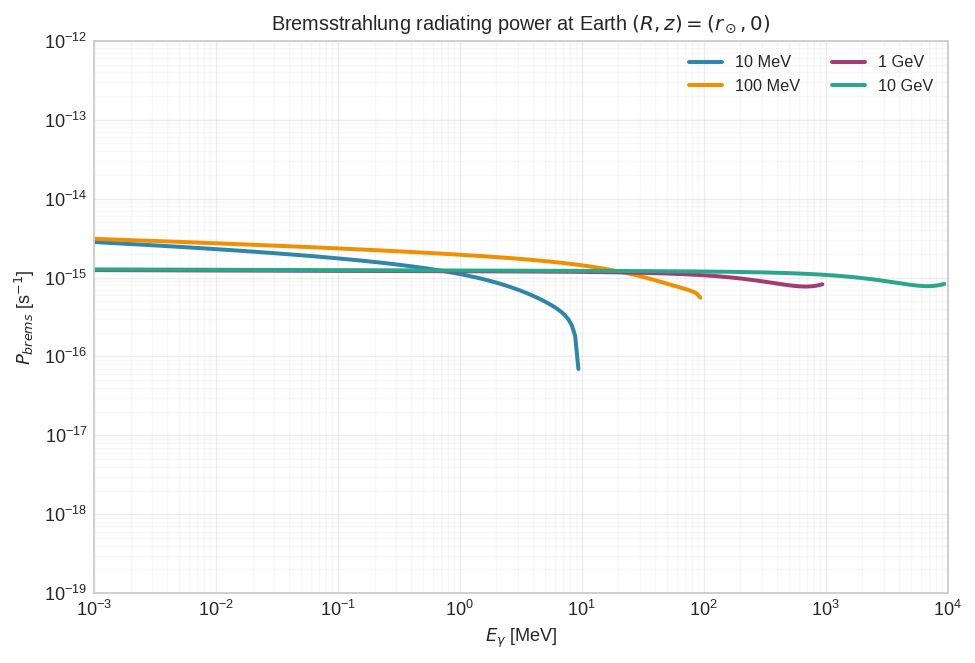

Peak P_brems contributions at Ee=1 GeV:
   HI: max = 5.380e-16 s^-1
   H2: max = 3.228e-16 s^-1
  HII: max = 1.200e-16 s^-1
   He: max = 2.618e-16 s^-1

Relevant observatories (energy coverage):
- keV to MeV: INTEGRAL, NuSTAR, COMPTEL (historical), future MeV missions (e-ASTROGAM/AMEGO-like)
- MeV to GeV: Fermi-LAT (lower-GeV edge), future MeV-GeV missions
- GeV and above tail: Fermi-LAT, and at higher energies CTA/HESS-like for bright cases


In [140]:
# Solution 3.2.3
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

R_earth, z_earth = rSun, 0.0
Ee_list = [1e-2, 1e-1, 1.0, 10.0]  # GeV
Ee_labels = ['10 MeV', '100 MeV', '1 GeV', '10 GeV']
colors = ['#2E86AB', '#F18F01', '#A23B72', '#2CA58D']

Eg_MeV = np.logspace(-3, 4, 260)
Eg_GeV = Eg_MeV * 1e-3

def Pbrems_total(Eg, Ee, R, z):
    # Sum over gas species used in the notebook model
    val = (PBrems(Eg, Ee, nHI, R, z)
           + PBrems(Eg, Ee, nH2, R, z)
           + PBrems(Eg, Ee, nHII, R, z)
           + PBrems(Eg, Ee, nHe, R, z))
    return val if np.isfinite(val) and (val > 0) else np.nan

fig, ax = plt.subplots(figsize=(7.6, 5.2))
for Ee, lab, col in zip(Ee_list, Ee_labels, colors):
    vals = np.array([Pbrems_total(Eg, Ee, R_earth, z_earth) for Eg in Eg_GeV])
    ax.loglog(Eg_MeV, vals, lw=2.2, color=col, label=lab)

ax.set_xlim(1e-3, 1e4)
ax.set_ylim(1e-19, 1e-12)
ax.set_xlabel(r'$E_\gamma$ [MeV]')
ax.set_ylabel(r'$P_{brems}$ [s$^{-1}$]')
ax.set_title(r'Bremsstrahlung radiating power at Earth $(R,z)=(r_\odot,0)$')
ax.grid(True, which='major', alpha=0.35)
ax.grid(True, which='minor', alpha=0.15)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

# Optional: show gas-species hierarchy for Ee=1 GeV
Ee_ref = 1.0
spec_names = ['HI', 'H2', 'HII', 'He']
spec_funcs = [nHI, nH2, nHII, nHe]
print('Peak P_brems contributions at Ee=1 GeV:')
for nm, fn in zip(spec_names, spec_funcs):
    v = np.array([PBrems(Eg, Ee_ref, fn, R_earth, z_earth) for Eg in Eg_GeV])
    print(f'  {nm:>3}: max = {np.nanmax(v):.3e} s^-1')

print('\nRelevant observatories (energy coverage):')
print('- keV to MeV: INTEGRAL, NuSTAR, COMPTEL (historical), future MeV missions (e-ASTROGAM/AMEGO-like)')
print('- MeV to GeV: Fermi-LAT (lower-GeV edge), future MeV-GeV missions')
print('- GeV and above tail: Fermi-LAT, and at higher energies CTA/HESS-like for bright cases')


### Question 3.3.1 (Section 3.3)
Solve the diffusion-loss equation when diffusion is negligible:
$$-\frac{\partial}{\partial E_e}\left[b_{tot}(E_e,\vec x)\,n_e(E_e,\vec x)\right]=Q_e^{DM}(E_e,\vec x).$$
With boundary condition $n_e(E_{max},\vec x)=0$, the solution is
$$n_e(E_e,\vec x)=\frac{1}{b_{tot}(E_e,\vec x)}\int_{E_e}^{E_{max}} dE'\,Q_e^{DM}(E',\vec x).$$
This applies to ROIs close to the GC where losses dominate over diffusion.

In [141]:
# Solution 3.3.1
import numpy as np

def ne_no_diffusion(Ee_grid, Qe_grid, btot_grid):
    """
    Solve n_e(E) = 1/b(E) * ∫_E^{Emax} dE' Q_e(E') on a monotonic Ee grid.

    Parameters
    ----------
    Ee_grid : array-like
        Electron energies in GeV (ascending).
    Qe_grid : array-like
        Source term Q_e(E) on Ee_grid, in GeV^-1 cm^-3 s^-1.
    btot_grid : array-like
        Total energy-loss coefficient b_tot(E), in GeV s^-1.

    Returns
    -------
    ne_grid : ndarray
        Electron density n_e(E), in GeV^-1 cm^-3.
    """
    E = np.asarray(Ee_grid, dtype=float)
    Q = np.asarray(Qe_grid, dtype=float)
    b = np.asarray(btot_grid, dtype=float)

    if np.any(np.diff(E) <= 0):
        raise ValueError('Ee_grid must be strictly increasing.')

    # Cumulative integral from high energy to low energy
    # I(E_i) = ∫_{E_i}^{Emax} Q(E') dE'
    I = np.zeros_like(E)
    for i in range(len(E)-2, -1, -1):
        dE = E[i+1] - E[i]
        I[i] = I[i+1] + 0.5 * (Q[i+1] + Q[i]) * dE

    eps = 1e-40
    ne = I / np.maximum(b, eps)
    return ne

# Symbolic-like helper expressions for Q_e^DM (normalization only)
def Qe_annihilation(Ee, rhoDM, mDM, sigmav, dNe_dE):
    # Q_e = 1/2 * <sv> * (rhoDM/mDM)^2 * dNe/dE
    return 0.5 * sigmav * (rhoDM / mDM)**2 * dNe_dE(Ee)

def Qe_decay(Ee, rhoDM, mDM, Gamma, dNe_dE):
    # Q_e = Gamma * (rhoDM/mDM) * dNe/dE
    return Gamma * (rhoDM / mDM) * dNe_dE(Ee)

print('3.3.1: Implemented no-diffusion solution n_e(E)=1/b(E) * integral_E^Emax Q(E\' ) dE\' .')
print('Use ne_no_diffusion(...) once Q_e(E,x) and b_tot(E,x) are defined at the target position.')


3.3.1: Implemented no-diffusion solution n_e(E)=1/b(E) * integral_E^Emax Q(E' ) dE' .
Use ne_no_diffusion(...) once Q_e(E,x) and b_tot(E,x) are defined at the target position.


### Question 3.3.2 (Section 3.3)
Implement the energy-loss coefficients at Earth $(R,z)=(r_\odot,0)$:
- Radiative: $b_{IC}$, $b_{syn}$, $b_{brems}$ from Eq. (22)
- Non-radiative: $b_{Coul}$ (Eq. 23) and $b_{ion}$ (Eq. 24)
Then plot them vs $E_e$ from 1 MeV to 1 GeV and identify the dominant contributions.

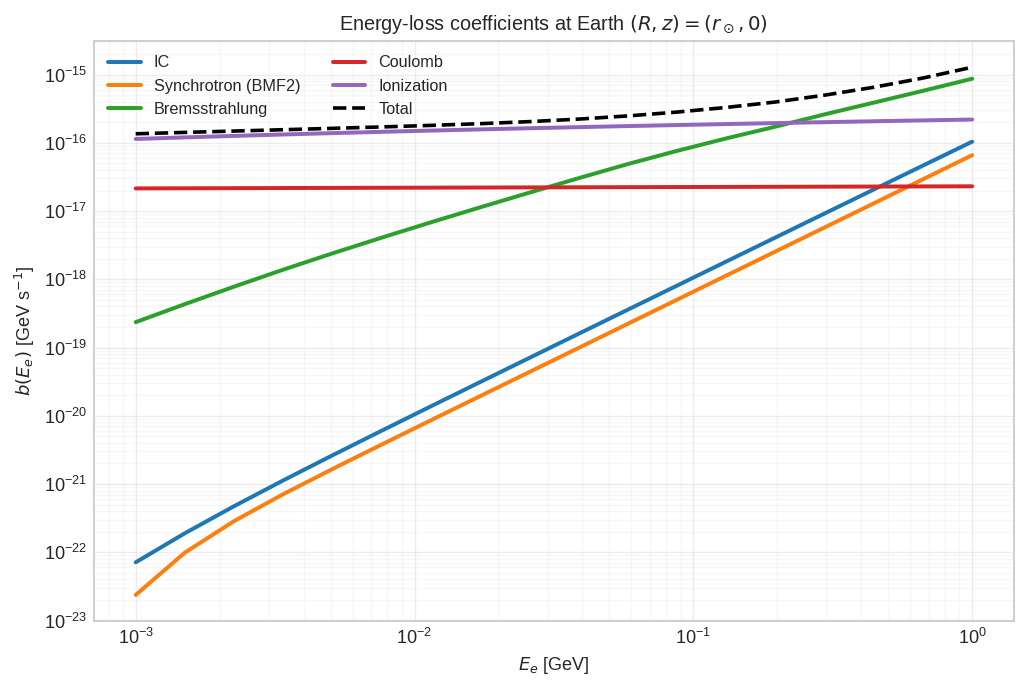

Ee ~ 1.000e-03 GeV -> dominant: Ion, values: IC=7.11e-23, Syn=2.37e-23, Brems=2.35e-19, Coul=2.15e-17, Ion=1.14e-16
Ee ~ 1.145e-02 GeV -> dominant: Ion, values: IC=1.38e-20, Syn=8.59e-21, Brems=6.84e-18, Coul=2.20e-17, Ion=1.51e-16
Ee ~ 8.733e-02 GeV -> dominant: Ion, values: IC=8.07e-19, Syn=5.02e-19, Brems=7.62e-17, Coul=2.25e-17, Ion=1.82e-16
Ee ~ 1.000e+00 GeV -> dominant: Brems, values: IC=1.04e-16, Syn=6.59e-17, Brems=8.69e-16, Coul=2.31e-17, Ion=2.19e-16

Typical outcome in this setup: low-E losses are mostly Coulomb/ionization/brems, while at higher E radiative losses (IC, synchrotron) become dominant.


In [142]:
# Solution 3.3.2
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

R_earth, z_earth = rSun, 0.0
B_model = BMF2  # choose one benchmark magnetic-field model

# Ionization energies (GeV)
DeltaE_HI = 15.0e-9
DeltaE_He = 41.5e-9

def PIC_total(Eg, Ee, R, z):
    return (PIC(Eg, Ee, nCMB)
            + PIC(Eg, Ee, nIRc, R, z)
            + PIC(Eg, Ee, nIRw, R, z)
            + PIC(Eg, Ee, nOpt, R, z))

def Pbrems_total(Eg, Ee, R, z):
    return (PBrems(Eg, Ee, nHI, R, z)
            + PBrems(Eg, Ee, nH2, R, z)
            + PBrems(Eg, Ee, nHII, R, z)
            + PBrems(Eg, Ee, nHe, R, z))

def b_IC(Ee, R, z):
    Eg_min = max(1e-12, Ee * 1e-8)
    Eg_max = Ee * (1 - 1e-6)
    Eg_grid = np.logspace(np.log10(Eg_min), np.log10(Eg_max), 44)
    vals = np.array([PIC_total(Eg, Ee, R, z) for Eg in Eg_grid])
    vals = np.where(np.isfinite(vals) & (vals > 0), vals, 0.0)
    return np.trapezoid(vals, Eg_grid)

def b_syn(Ee, R, z, B):
    gamma = Ee / me
    nu_c = GeVinsec * 3/(2*np.pi) * gamma**2 * e * B(R, z) * GaussinGeV2 / me
    nu_min = max(1e2, nu_c * 1e-6)
    nu_max = nu_c * 1e3
    nu_grid = np.logspace(np.log10(nu_min), np.log10(nu_max), 120)
    vals = np.array([PSyn(nu, Ee, B, R, z) for nu in nu_grid])
    vals = np.where(np.isfinite(vals) & (vals > 0), vals, 0.0)
    return np.trapezoid(vals, nu_grid)

def b_brems(Ee, R, z):
    Eg_min = max(1e-9, Ee * 1e-8)
    Eg_max = Ee * (1 - 1e-6)
    Eg_grid = np.logspace(np.log10(Eg_min), np.log10(Eg_max), 70)
    vals = np.array([Pbrems_total(Eg, Ee, R, z) for Eg in Eg_grid])
    vals = np.where(np.isfinite(vals) & (vals > 0), vals, 0.0)
    return np.trapezoid(vals, Eg_grid)

def b_coul(Ee, R, z):
    nfree = nHII(R, z)  # cm^-3
    if nfree <= 0:
        return 0.0

    # Plasma energy (natural units)
    nfree_nat = nfree / (GeVincm**3)  # GeV^3
    Ep = e * np.sqrt(me * nfree_nat)

    bracket = np.log(Ee / me) + 2.0 * np.log(me / Ep)
    bracket = max(bracket, 0.0)

    return (3 * sigmaT / 4) * (GeVinsec / GeVincm) * me * nfree * bracket

def b_ion(Ee, R, z):
    # Dominant neutral/atomic contributions from HI and He
    n_HI = nHI(R, z)
    n_He = nHe(R, z)

    term_HI = n_HI * 1.0 * (np.log(Ee / me) + (2.0/3.0) * np.log(me / DeltaE_HI))
    term_He = n_He * 2.0 * (np.log(Ee / me) + (2.0/3.0) * np.log(me / DeltaE_He))
    bracket = max(term_HI + term_He, 0.0)

    return (9 * sigmaT / 4) * (GeVinsec / GeVincm) * me * bracket

# Energy grid: 1 MeV -> 1 GeV
Ee_grid = np.logspace(-3, 0, 18)  # GeV

bIC = np.array([b_IC(Ee, R_earth, z_earth) for Ee in Ee_grid])
bSyn = np.array([b_syn(Ee, R_earth, z_earth, B_model) for Ee in Ee_grid])
bBrems = np.array([b_brems(Ee, R_earth, z_earth) for Ee in Ee_grid])
bCoul = np.array([b_coul(Ee, R_earth, z_earth) for Ee in Ee_grid])
bIon = np.array([b_ion(Ee, R_earth, z_earth) for Ee in Ee_grid])
bTot = bIC + bSyn + bBrems + bCoul + bIon

plt.figure(figsize=(8, 5.4))
plt.loglog(Ee_grid, bIC, lw=2.2, label='IC')
plt.loglog(Ee_grid, bSyn, lw=2.2, label='Synchrotron (BMF2)')
plt.loglog(Ee_grid, bBrems, lw=2.2, label='Bremsstrahlung')
plt.loglog(Ee_grid, bCoul, lw=2.2, label='Coulomb')
plt.loglog(Ee_grid, bIon, lw=2.2, label='Ionization')
plt.loglog(Ee_grid, bTot, 'k--', lw=2.0, label='Total')

plt.xlabel(r'$E_e$ [GeV]')
plt.ylabel(r'$b(E_e)$ [GeV s$^{-1}$]')
plt.title(r'Energy-loss coefficients at Earth $(R,z)=(r_\odot,0)$')
plt.grid(True, which='major', alpha=0.35)
plt.grid(True, which='minor', alpha=0.15)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

# Dominance summary
components = {
    'IC': bIC,
    'Syn': bSyn,
    'Brems': bBrems,
    'Coul': bCoul,
    'Ion': bIon,
}

for Etest in [1e-3, 1e-2, 1e-1, 1.0]:
    i = np.argmin(np.abs(Ee_grid - Etest))
    vals = {k: v[i] for k, v in components.items()}
    dom = max(vals, key=vals.get)
    print(f'Ee ~ {Ee_grid[i]:.3e} GeV -> dominant: {dom}, values: ' + ', '.join([f'{k}={vals[k]:.2e}' for k in vals]))

print('\nTypical outcome in this setup: low-E losses are mostly Coulomb/ionization/brems, while at higher E radiative losses (IC, synchrotron) become dominant.')
